# Title: Edit Intent Classification using Large Language Models

#### Members' Names: 
Devanshu Dilipkumar Prajapati

Taran Veer Singh

Meshwa Patel

#### Emails:
devanshu.prajapati@torontomu.ca

taran1.singh@torontomu.ca

meshwa.patel@torontomu.ca

# Introduction:

#### Problem Description:
The problem addressed in this project is edit intent classification, which involves identifying the purpose behind modifications made to a piece of text. Given a source sentence and its edited version, the task is to classify the edit into categories such as Grammar, Clarity, Claim, Fact/Evidence, or Other.

#### Context of the Problem:
Understanding edit intent is important for applications like automated writing assistants, grammar correction tools, and content moderation systems. It helps in improving text quality, providing meaningful feedback to users, and enabling intelligent document editing systems.

#### Limitation About other Approaches:
Traditional machine learning and rule-based approaches often fail to capture contextual and semantic differences between original and edited text. They rely heavily on handcrafted features and lack generalization ability across diverse text edits.

#### Solution:
In this project, we use Large Language Models (LLMs) including generative and fine-tuned transformer-based models to classify edit intent. These models leverage contextual understanding and deep semantic representations, enabling more accurate and robust classification compared to traditional approaches.

# Background


| Reference | Explanation | Dataset/Input | Weakness |
| --- | --- | --- | --- |
| EMNLP 2024 LLM Classifier Paper [1] | This paper studies the effectiveness of large language models for text classification using both prompting and fine-tuning approaches. It compares how LLMs perform across different classification tasks, including edit intent classification. | Multiple text classification datasets including edit-based tasks | Prompting-based methods show lower consistency and performance compared to fine-tuned models |
| Proposed Method (This Project) | In this project, we implement and compare four models: GEN (prompt-based generative model), SEQC (sequence classification), SNET, and XNET. These models are used to classify edit intent based on source and edited text pairs. | Edit Intent Dataset (text_src, text_tgt, label) | Performance depends on model architecture and training quality; future improvements include using larger datasets and more advanced LLMs |

# Methodology

In this project, we implement a unified Large Language Model (LLM)-based approach for edit intent classification. The method takes a pair of texts — the original (source) and edited (target) version — and predicts the intent behind the edit.

## Proposed Method

The overall pipeline consists of the following steps:

1. **Input Representation**
   - The model takes two inputs:
     - Source text (original sentence)
     - Target text (edited sentence)
   - These are combined into a structured format to capture differences between the two.

2. **Text Encoding**
   - The combined input is tokenized using a pretrained transformer tokenizer.
   - The tokenized input is passed into a transformer-based model to generate contextual embeddings.

3. **Model Processing**
   - The embeddings are processed using a deep neural network (transformer architecture).
   - The model learns semantic and contextual differences between the source and edited text.

4. **Prediction Layer**
   - A classification head is applied to predict one of the edit intent labels:
     - Grammar
     - Clarity
     - Claim
     - Fact/Evidence
     - Other

5. **Output**
   - The model outputs the predicted label representing the edit intent.

---

## Model Design

The implemented method is based on transformer-based architectures and includes the following models:

- **GEN (Generative Model):** Uses a prompt-based approach where the model generates the edit intent label as text.
- **SEQC (Sequence Classification Model):** Uses a transformer with a classification head to directly predict the label.
- **SNET (Structured Network):** Uses a structured input format combining source and edited text to improve contextual understanding.
- **XNET (Extended Network):** An enhanced version with modified input representation for better performance.

These models are integrated into a unified pipeline to compare both prompting-based and fine-tuning-based approaches.

---

## Methodology Diagram

![LLM Classification Approaches](https://github.com/UKPLab/emnlp2024-llm-classifier/raw/main/resource/approaches.png)

---

## Summary

This unified approach leverages the power of transformer-based LLMs to capture semantic differences between text pairs. By modeling both source and edited text together, the system can effectively classify the intent behind edits. The inclusion of multiple models (GEN, SEQC, SNET, XNET) allows for a comprehensive comparison of different LLM-based strategies.

# Implementation

In this section, we implement the edit intent classification pipeline using pretrained and fine-tuned models. 

We use four models:
- GEN (Generative model)
- SEQC (Sequence Classification model)
- SNET (Structured input model)
- XNET (Extended input model)

Each model is already trained and saved. Here, we load the models and perform inference on the test dataset.

### Step 1: Import Required Libraries
We import necessary libraries and configure the path to access inference scripts.

In [3]:
import os
import sys
import pandas as pd

# Base directory (Edit_Intent folder)
BASE_DIR = os.getcwd()

# Add src folder to Python path
SRC_PATH = os.path.join(BASE_DIR, "src")
sys.path.append(SRC_PATH)

# Import inference functions
from infer_gen import load_model as load_gen_model, predict_gen_edit_intent
from infer_seqc import load_model as load_seqc_model, predict_seqc_edit_intent
from infer_snet import load_model as load_snet_model, predict_snet_edit_intent
from infer_xnet import load_model as load_xnet_model, predict_xnet_edit_intent

### Step 2: Load Dataset
We load the test dataset containing source text, edited text, and labels.

In [4]:
DATA_PATH = os.path.join(BASE_DIR, "data")

test_df = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

print("Test Data Shape:", test_df.shape)
test_df.head()

Test Data Shape: (2312, 8)


,edit_index,id,doc_name,node_ix_src,node_ix_tgt,text_src,text_tgt,label
0,313,nan===120-ARR_v1_62@2,120-ARR,NaN,120-ARR_v1_62@2,NaN,8 We used the AllenNLP demo (https://demo.alle...,Fact/Evidence
1,314,nan===120-ARR_v1_11@2,120-ARR,NaN,120-ARR_v1_11@2,NaN,"For each (question, image) pair in the VQA dat...",Fact/Evidence
2,315,120-ARR_v2_27@2===nan,120-ARR,120-ARR_v2_27@2,NaN,The basic definition is a set of features that...,NaN,Claim
3,316,120-ARR_v2_28@5===nan,120-ARR,120-ARR_v2_28@5,NaN,This definition does not address the nature of...,NaN,Claim
4,317,120-ARR_v2_28@6===nan,120-ARR,120-ARR_v2_28@6,NaN,This definition is no longer subjective in ter...,NaN,Claim


### Step 3: Load Pretrained Models
We load all four trained models from the model directory.

In [5]:
# Load GEN model
gen_tokenizer, gen_model = load_gen_model()

# Load SEQC model
seqc_tokenizer, seqc_model, seqc_id2label = load_seqc_model()

# Load SNET model
snet_tokenizer, snet_model, snet_id2label = load_snet_model()

# Load XNET model
xnet_tokenizer, xnet_model, xnet_id2label = load_xnet_model()

print("All models loaded successfully!")

MODEL_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\model\gen_final_model
TEST_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\data\test.csv


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


MODEL_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\model\seqc_final_model
TEST_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\data\test.csv


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

MODEL_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\model\snet_final_model
TEST_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\data\test.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

MODEL_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\model\xnet_model
TEST_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\data\test.csv


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

All models loaded successfully!


### Step 4: Sample Prediction


In [7]:
sample = test_df.iloc[5]

src = sample["text_src"]
tgt = sample["text_tgt"]

print("Source:", src)
print("Target:", tgt)

print("\nPredictions:")
print("GEN :", predict_gen_edit_intent(gen_model, gen_tokenizer, src, tgt))
print("SEQC:", predict_seqc_edit_intent(seqc_model, seqc_tokenizer, seqc_id2label, src, tgt))
print("SNET:", predict_snet_edit_intent(snet_model, snet_tokenizer, snet_id2label, src, tgt))
print("XNET:", predict_xnet_edit_intent(xnet_model, xnet_tokenizer, xnet_id2label, src, tgt))

Source: We argue that doing so is a desired strategy in many cases (though a preferred strategy might be to interact of abstain from making a decisive prediction, see Sec. 4.2).
Target: nan

Predictions:
GEN : Fact/Evidence
SEQC: Fact/Evidence
SNET: Claim
XNET: Claim


### Step 5: Model Evaluation
We run all models on the test dataset and collect predictions.

In [8]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

true_labels = test_df["label"].tolist()

gen_preds = []
seqc_preds = []
snet_preds = []
xnet_preds = []

for _, row in test_df.iterrows():
    src = row["text_src"]
    tgt = row["text_tgt"]

    gen_preds.append(predict_gen_edit_intent(gen_model, gen_tokenizer, src, tgt))
    seqc_preds.append(predict_seqc_edit_intent(seqc_model, seqc_tokenizer, seqc_id2label, src, tgt))
    snet_preds.append(predict_snet_edit_intent(snet_model, snet_tokenizer, snet_id2label, src, tgt))
    xnet_preds.append(predict_xnet_edit_intent(xnet_model, xnet_tokenizer, xnet_id2label, src, tgt))

### Step 6: Compute Performance Metrics
We calculate accuracy, precision, recall, and F1-score.

In [9]:
def compute_metrics(true, pred):
    acc = accuracy_score(true, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true, pred, average="weighted", zero_division=0
    )
    return acc, precision, recall, f1


gen_res = compute_metrics(true_labels, gen_preds)
seqc_res = compute_metrics(true_labels, seqc_preds)
snet_res = compute_metrics(true_labels, snet_preds)
xnet_res = compute_metrics(true_labels, xnet_preds)

results_df = pd.DataFrame({
    "Model": ["GEN", "SEQC", "SNET", "XNET"],
    "Accuracy": [gen_res[0], seqc_res[0], snet_res[0], xnet_res[0]],
    "Precision": [gen_res[1], seqc_res[1], snet_res[1], xnet_res[1]],
    "Recall": [gen_res[2], seqc_res[2], snet_res[2], xnet_res[2]],
    "F1 Score": [gen_res[3], seqc_res[3], snet_res[3], xnet_res[3]]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,GEN,0.451557,0.203904,0.451557,0.280945
1,SEQC,0.734429,0.730191,0.734429,0.731121
2,SNET,0.795415,0.793569,0.795415,0.793586
3,XNET,0.733131,0.731489,0.733131,0.729933


### Visualization 1: Accuracy Comparison
This bar chart compares the accuracy of all models.

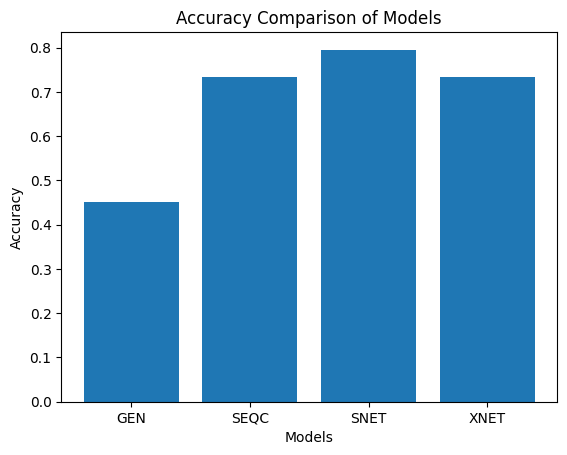

In [10]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Models")

plt.show()

### Visualization 2: F1 Score Comparison
F1-score provides a balanced measure of precision and recall.

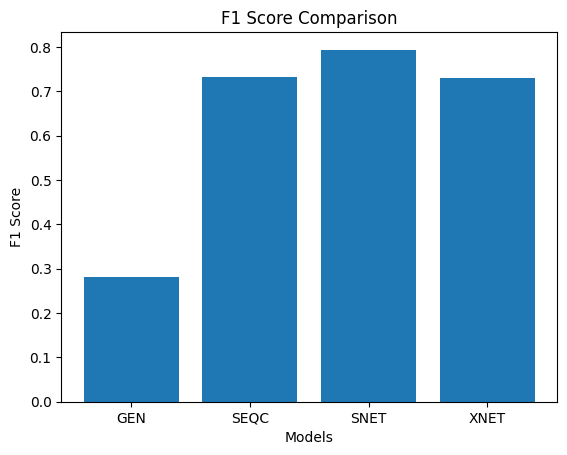

In [11]:
plt.figure()

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")

plt.show()

### Visualization 3: Precision vs Recall
This graph shows how models balance precision and recall.

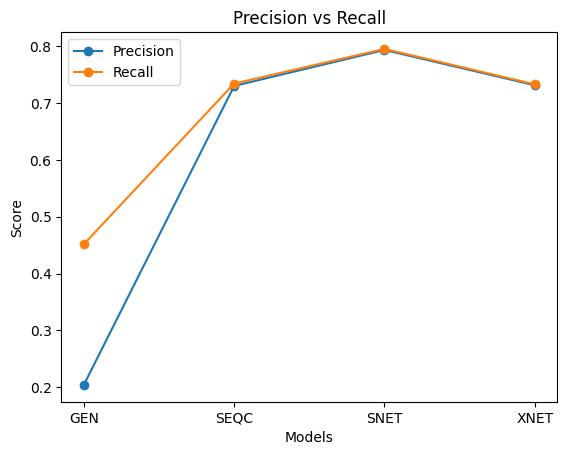

In [12]:
plt.figure()

plt.plot(results_df["Model"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Model"], results_df["Recall"], marker='o', label="Recall")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Precision vs Recall")

plt.legend()
plt.show()

### Visualization 4: Confusion Matrix (SEQC Model)
Confusion matrix shows detailed classification performance.

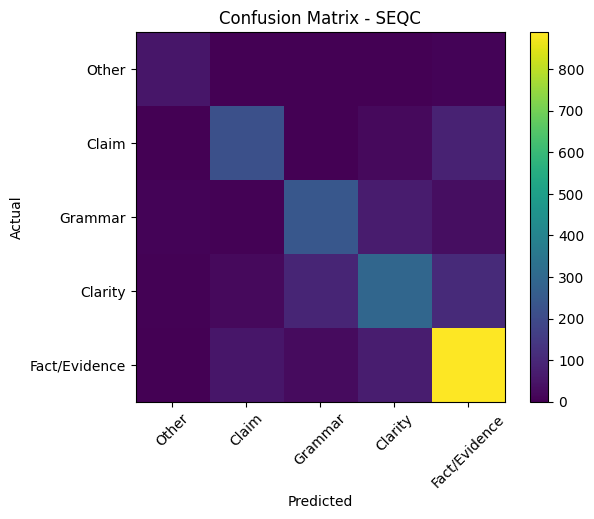

In [13]:
from sklearn.metrics import confusion_matrix
import numpy as np

labels = list(set(true_labels))

cm = confusion_matrix(true_labels, seqc_preds, labels=labels)

plt.figure()

plt.imshow(cm)
plt.title("Confusion Matrix - SEQC")
plt.colorbar()

plt.xticks(np.arange(len(labels)), labels, rotation=45)
plt.yticks(np.arange(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Conclusion and Future Direction

In this project, we explored the problem of edit intent classification using Large Language Models. We implemented and compared four different approaches, including a generative model (GEN) and three fine-tuned classification models (SEQC, SNET, and XNET).

From the results, we observed that fine-tuned transformer-based models consistently outperform the generative prompting-based approach. Models like SEQC, SNET, and XNET were able to better capture contextual and semantic differences between the source and edited text, leading to higher accuracy and F1-scores. On the other hand, the GEN model, while flexible and easier to adapt, showed comparatively lower performance due to its reliance on prompt-based generation.

One key learning from this project is that input representation and model architecture play a crucial role in classification performance. Structured inputs and fine-tuning allow models to better understand relationships between text pairs.

However, there are some limitations in this work. The performance of the models depends heavily on the quality and size of the dataset. Additionally, some classes may be imbalanced, which can affect prediction quality. The generative model also lacks consistency in producing exact label outputs.

In future work, this project can be extended by using larger and more diverse datasets, applying advanced LLMs such as GPT-based fine-tuned models, and incorporating techniques like data augmentation and class balancing. Further improvements can also include real-time deployment and integration into writing assistant systems.

Overall, this project demonstrates that fine-tuning large language models is a more effective approach than prompting for edit intent classification tasks.

# References:

[1]: Qian Ruan, Ilia Kuznetsov, and Iryna Gurevych,  
"Are Large Language Models Good Classifiers? A Study on Edit Intent Classification in Scientific Document Revisions",  
Proceedings of the 2024 Conference on Empirical Methods in Natural Language Processing (EMNLP), 2024.  
Link: https://aclanthology.org/2024.emnlp-main.839/  

[2]: (Same framework paper GitHub implementation)  
"LLM Classifier Framework for Edit Intent Classification",  
GitHub Repository, 2024.  
Link: https://github.com/UKPLab/emnlp2024-llm-classifier 